# Detection Debug Dashboard

Metric mở rộng, AP theo class, phân loại lỗi, slider validation và tune threshold.

In [1]:
from pathlib import Path
import sys

from IPython.display import display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.helper import (
    detection_error_table,
    load_prediction_analysis,
    per_class_ap_table,
    plot_detection_errors,
    plot_per_class_ap,
    plot_threshold_tuning_heatmap,
    prediction_metrics_table,
    show_prediction_analysis_slider,
    show_predictions_slider,
    tune_prediction_thresholds,
)

PREDICTIONS = PROJECT_ROOT / "saved_results/predictions.json"
RAW_PREDICTIONS = PROJECT_ROOT / "saved_results/predictions_raw.json"
GROUND_TRUTH = PROJECT_ROOT / "public/annotations/val.json"
VAL_IMAGES = PROJECT_ROOT / "public/val/images"
CLASSES = PROJECT_ROOT / "public/classes.json"


## Metric tổng quan và AP theo class

,mAP@0.5,mAP@0.75,mAP@0.5:0.95,precision,recall,ground_truth_boxes,predictions
0,0.7807,0.4998,0.4679,0.6642,0.8357,2021,2543


,class,AP@0.5,AP@0.75,AP@0.5:0.95,precision,recall,ground_truth,predictions
0,dog,0.8468,0.6503,0.5501,0.7532,0.8592,206,235
1,cat,0.8709,0.5907,0.5464,0.8168,0.8864,176,191
2,person,0.8396,0.5110,0.4874,0.6817,0.8715,1074,1373
3,car,0.7638,0.4709,0.4548,0.6543,0.8092,283,350
4,chair,0.5824,0.2762,0.3010,0.4848,0.6773,282,394


<Axes: title={'center': 'Average Precision by class'}, xlabel='class', ylabel='AP'>

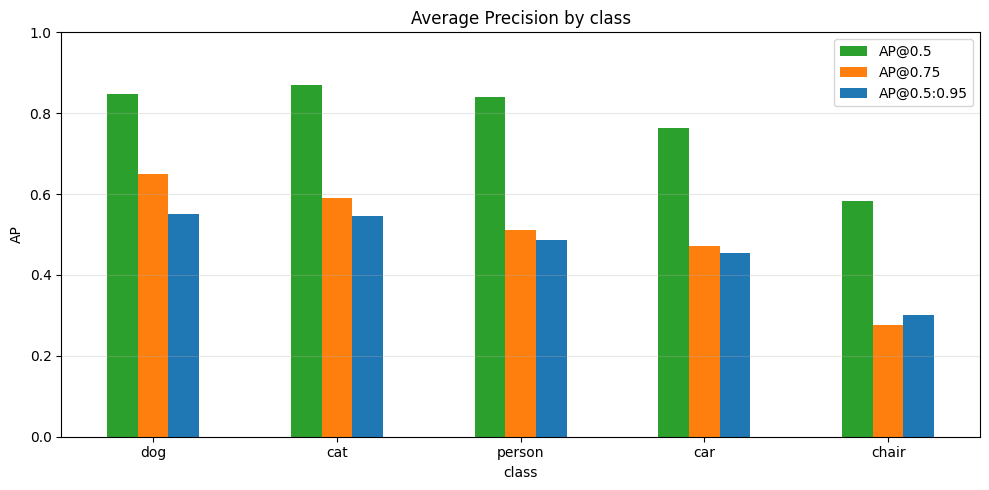

In [2]:
analysis = load_prediction_analysis(PREDICTIONS, GROUND_TRUTH)
display(prediction_metrics_table(analysis).round(4))
display(per_class_ap_table(analysis).round(4))
plot_per_class_ap(analysis)


## Phân loại lỗi chính

,error_type,count
0,background_false_positive,577
1,missed_detection,332
2,localization_error,176
3,duplicate_detection,78
4,classification_error,23


{'good': 921, 'incorrect': 344, 'missed': 91, 'mixed': 144}

<Axes: title={'center': 'Detection error categories'}, xlabel='Count'>

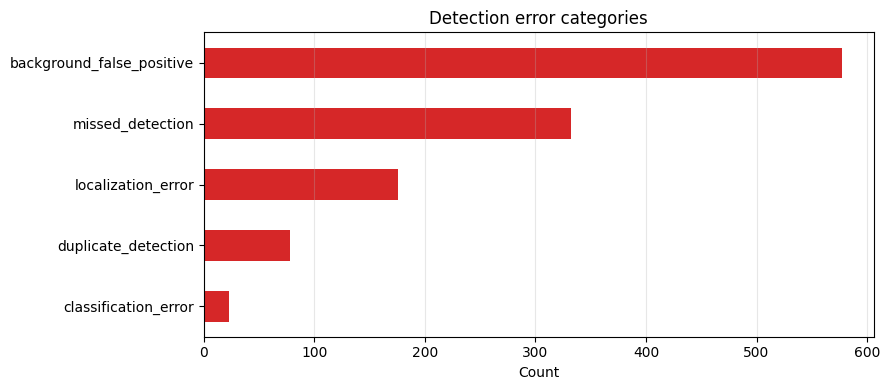

In [3]:
display(detection_error_table(analysis))
display(analysis["errors"]["image_category_counts"])
plot_detection_errors(analysis)


## Slider 50 ảnh validation

Prediction đúng màu xanh, prediction lỗi màu đỏ, ground truth nét đứt màu đen.

In [4]:
show_prediction_analysis_slider(
    analysis,
    image_dir=VAL_IMAGES,
    categories=("good", "incorrect", "missed", "mixed"),
    max_images=50,
)


IntSlider(value=0, continuous_update=False, description='Index', max=49)

## Slider toàn bộ prediction

In [ ]:
show_predictions_slider(
    PREDICTIONS,
    image_dir=VAL_IMAGES,
    classes_path=CLASSES,
    show_ground_truth=True,
    ground_truth_path=GROUND_TRUTH,
)


IntSlider(value=0, continuous_update=False, description='Index', max=1499)

## Tune confidence và NMS threshold

Chạy `bash script.sh predict-raw` trước để tạo prediction với score thấp và NMS rộng.

In [6]:
if RAW_PREDICTIONS.exists():
    threshold_results = tune_prediction_thresholds(
        RAW_PREDICTIONS,
        GROUND_TRUTH,
        confidence_thresholds=[0.2, 0.3, 0.4, 0.5, 0.6, 0.7],
        nms_thresholds=[0.3, 0.4, 0.5, 0.6, 0.7],
    )
    display(threshold_results.head(15).round(4))
    plot_threshold_tuning_heatmap(threshold_results, metric="mAP")
else:
    print("Chưa có predictions_raw.json. Chạy: bash script.sh predict-raw")


Chưa có predictions_raw.json. Chạy: bash script.sh predict-raw
